[strona z danymi TCGA](https://xenabrowser.net/datapages/?cohort=TCGA%20Pan-Cancer%20(PANCAN)&removeHub=https%3A%2F%2Fucscpublic.xenahubs.net)

[STRING](https://string-db.org/cgi/download?sessionId=bjq23DdcQ9YK&species_text=Homo+sapiens&settings_expanded=0&min_download_score=0&filter_redundant_pairs=0&delimiter_type=txt)

[artykuł od Szmuca](https://dl.acm.org/doi/10.1145/3670685#sec-5)

[GCCExplainer](https://github.com/CharlotteMagister/GCExplainer/blob/main/src/k_clustering/Mutag_Test.ipynb)

In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np

#import networkx as nx
#import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

import torch
from torch.nn import Linear
import torch.nn.functional as F

#from torch_geometric.utils import to_networkx
from torch_geometric.nn import AttentionalAggregation, global_add_pool, GCNConv
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
import torch_geometric.utils as pyg_utils


## Preprocessing

Tego nie trzeba odpalać.

### Ładowanie i Preprocessing Danych Biomedycznych

Tu pobieramy dane ekspresji genów i filtrujemy topowe geny (najwyższa wariancja)

In [ ]:
# Batch effects normalized miRNA data
# https://xenabrowser.net/datapages/?dataset=EB%2B%2BAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena&host=https%3A%2F%2Fpancanatlas.xenahubs.net&removeHub=https%3A%2F%2Fucscpublic.xenahubs.net

df = pd.read_csv('EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena.gz', sep='\t', index_col=0)

# Pozbywamy się genów o nazwach czysto numerycznych
df = df[~df.index.str.isnumeric()]

df_t = df.T

# Wybór Top genów (1000)
gene_variance = df_t.var().sort_values(ascending=False)
top_genes = gene_variance.head(1000).index

In [ ]:
# sample type and primary disease
# https://xenabrowser.net/datapages/?dataset=TCGA_phenotype_denseDataOnlyDownload.tsv&host=https%3A%2F%2Fpancanatlas.xenahubs.net&removeHub=https%3A%2F%2Fucscpublic.xenahubs.net

pheno = pd.read_csv('TCGA_phenotype_denseDataOnlyDownload.tsv.gz', sep='\t')
pheno = pheno[['sample', '_primary_disease']] # Interesują nas tylko te kolumny

data_with_labels = pd.merge(df_t, pheno, left_index=True, right_on='sample')

le = LabelEncoder()
data_with_labels['label'] = le.fit_transform(data_with_labels['_primary_disease'])

# Zapisz mapowanie, żeby wiedzieć co jest czym
class_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(class_mapping)

{np.int64(0): 'acute myeloid leukemia', np.int64(1): 'adrenocortical cancer', np.int64(2): 'bladder urothelial carcinoma', np.int64(3): 'brain lower grade glioma', np.int64(4): 'breast invasive carcinoma', np.int64(5): 'cervical & endocervical cancer', np.int64(6): 'cholangiocarcinoma', np.int64(7): 'colon adenocarcinoma', np.int64(8): 'diffuse large B-cell lymphoma', np.int64(9): 'esophageal carcinoma', np.int64(10): 'glioblastoma multiforme', np.int64(11): 'head & neck squamous cell carcinoma', np.int64(12): 'kidney chromophobe', np.int64(13): 'kidney clear cell carcinoma', np.int64(14): 'kidney papillary cell carcinoma', np.int64(15): 'liver hepatocellular carcinoma', np.int64(16): 'lung adenocarcinoma', np.int64(17): 'lung squamous cell carcinoma', np.int64(18): 'mesothelioma', np.int64(19): 'ovarian serous cystadenocarcinoma', np.int64(20): 'pancreatic adenocarcinoma', np.int64(21): 'pheochromocytoma & paraganglioma', np.int64(22): 'prostate adenocarcinoma', np.int64(23): 'rectum 

In [ ]:
# Sprawdź ile jest próbek z każdego typu
print(data_with_labels['_primary_disease'].value_counts().head(10))

_primary_disease
breast invasive carcinoma                1218
kidney clear cell carcinoma               606
lung adenocarcinoma                       576
thyroid carcinoma                         572
uterine corpus endometrioid carcinoma     567
head & neck squamous cell carcinoma       566
lung squamous cell carcinoma              553
prostate adenocarcinoma                   550
brain lower grade glioma                  530
colon adenocarcinoma                      495
Name: count, dtype: int64


In [ ]:
top_10_diseases = data_with_labels['_primary_disease'].value_counts().head(10).index
df_diseases = data_with_labels[data_with_labels['_primary_disease'].isin(top_10_diseases)]
data_with_labels = df_diseases.reset_index(drop=True)
print(f"Finalny kształt danych: {data_with_labels.shape}")

Finalny kształt danych: (6233, 20505)


In [ ]:
le = LabelEncoder()
data_with_labels['label'] = le.fit_transform(data_with_labels['_primary_disease'])

# Zapisz mapowanie, żeby wiedzieć co jest czym
class_mapping = dict(zip(le.transform(le.classes_), le.classes_))
print(class_mapping)

{np.int64(0): 'brain lower grade glioma', np.int64(1): 'breast invasive carcinoma', np.int64(2): 'colon adenocarcinoma', np.int64(3): 'head & neck squamous cell carcinoma', np.int64(4): 'kidney clear cell carcinoma', np.int64(5): 'lung adenocarcinoma', np.int64(6): 'lung squamous cell carcinoma', np.int64(7): 'prostate adenocarcinoma', np.int64(8): 'thyroid carcinoma', np.int64(9): 'uterine corpus endometrioid carcinoma'}


In [ ]:
from sklearn.impute import SimpleImputer

X_raw = data_with_labels.drop(['sample', '_primary_disease', 'label'], axis=1)
y_raw = data_with_labels['label']

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

constant_filter = X_imputed.nunique() <= 1
X_filtered = X_imputed.loc[:, ~constant_filter]

print(f"Usunięto {constant_filter.sum()} genów o stałej wartości.")

Usunięto 233 genów o stałej wartości.


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Lista onkologiczna (Golden Genes)
golden_genes_list = [
    'TP53', 'MYC', 'EGFR', 'BRCA1', 'BRCA2', 'PTEN', 'KRAS', 'APC',
    'PIK3CA', 'RB1', 'BRAF', 'VHL', 'MTOR', 'ERBB2', 'MET', 'CTNNB1',
    'CDKN2A', 'AR', 'ESR1', 'IDH1', 'FGFR3', 'GATA3', 'TET2'
]

available_golden = [g for g in golden_genes_list if g in X_filtered.columns]

num_needed = 1000 - len(available_golden)
selector = SelectKBest(score_func=f_classif, k=num_needed)
selector.fit(X_filtered, y_raw)

stat_genes = X_filtered.columns[selector.get_support()].tolist()

top_genes = list(dict.fromkeys(available_golden + stat_genes))

print(f"Finalna liczba genów do modelu: {len(top_genes)}")

Finalna liczba genów do modelu: 997


In [ ]:
cols_to_keep = list(top_genes) + ['label']
df_ready = data_with_labels[cols_to_keep]

print(f"Finalny kształt danych: {df_ready.shape}")

Finalny kształt danych: (6233, 998)


### Budowa Topologii Grafu (STRING-DB)

Mapuje interakcje białkowe na indeksy wybranych genów.

To definiuje architekturę połączeń dla GNN.

In [ ]:
# 9606.protein.links.v12.0.txt.gz
# https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz

# 9606.protein.info.v12.0.txt.gz
# https://stringdb-downloads.org/download/protein.info.v12.0/9606.protein.info.v12.0.txt.gz

info = pd.read_csv('9606.protein.info.v12.0.txt.gz', sep='\t', usecols=['#string_protein_id', 'preferred_name'])
map_dict = dict(zip(info['#string_protein_id'], info['preferred_name']))

links = pd.read_csv('9606.protein.links.v12.0.txt.gz', sep=' ')

# Mapuj nazwy i filtruj
links['p1'] = links['protein1'].map(map_dict)
links['p2'] = links['protein2'].map(map_dict)

# Zostawiamy tylko interakcje między 1000 genami (top_genes)
mask = links['p1'].isin(top_genes) & links['p2'].isin(top_genes)
final_links = links[mask].copy()

final_links = final_links[final_links['combined_score'] >= 400]

In [ ]:
def create_edge_index(final_links, top_genes):
    """
    final_links: DataFrame z kolumnami 'p1' i 'p2' (nazwy genów ze STRING)
    top_genes: Lista lub Index z 1000 wybranymich genów w dokładnej kolejności w jakiej są w tabeli ekspresji
    """

    gene_to_idx = {gene: i for i, gene in enumerate(top_genes)}

    edge_src = final_links['p1'].map(gene_to_idx)
    edge_dst = final_links['p2'].map(gene_to_idx)

    valid_mask = edge_src.notna() & edge_dst.notna()
    edge_src = edge_src[valid_mask].astype(int)
    edge_dst = edge_dst[valid_mask].astype(int)

    edge_index = torch.tensor([edge_src.values, edge_dst.values], dtype=torch.long)
    edge_index, _ = pyg_utils.add_self_loops(edge_index, num_nodes=len(top_genes))
    return edge_index

edge_index = create_edge_index(final_links, top_genes)


print(f"Liczba krawędzi w grafie: {edge_index.shape[1]}")

Liczba krawędzi w grafie: 11199


C:\Users\kingu\AppData\Local\Temp\ipykernel_18656\1713076251.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edge_src.values, edge_dst.values], dtype=torch.long)


### Tworzenie Datasetu PyTorch Geometric

In [ ]:
train_df, temp_df = train_test_split(df_ready, test_size=0.2, stratify=df_ready['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

X_train_raw = train_df[top_genes]
X_val_raw = val_df[top_genes]
X_test_raw = test_df[top_genes]

constant_cols = X_train_raw.columns[X_train_raw.nunique() <= 1].tolist()
top_genes_clean = [g for g in top_genes if g not in constant_cols]


scaler = StandardScaler()
train_genes_scaled = scaler.fit_transform(X_train_raw[top_genes_clean])
val_genes_scaled = scaler.transform(X_val_raw[top_genes_clean])
test_genes_scaled = scaler.transform(X_test_raw[top_genes_clean])

train_genes_scaled = np.nan_to_num(train_genes_scaled)
val_genes_scaled = np.nan_to_num(val_genes_scaled)
test_genes_scaled = np.nan_to_num(test_genes_scaled)

num_nodes = len(top_genes_clean)
edge_index = create_edge_index(final_links, top_genes_clean)

def build_graph_dataset_clean(scaled_data, labels, edge_index):
    dataset = []
    for i in range(len(scaled_data)):
        x = torch.tensor(scaled_data[i], dtype=torch.float).view(-1, 1)
        y = torch.tensor([labels.iloc[i]], dtype=torch.long)
        graph = Data(x=x, edge_index=edge_index, y=y)
        dataset.append(graph)
    return dataset

train_dataset = build_graph_dataset_clean(train_genes_scaled, train_df['label'], edge_index)
val_dataset = build_graph_dataset_clean(val_genes_scaled, val_df['label'], edge_index)
test_dataset = build_graph_dataset_clean(test_genes_scaled, test_df['label'], edge_index)
print(f"Dane treningowe: {len(train_dataset)}, Dane walidacyjne: {len(val_dataset)}, Dane testowe: {len(test_dataset)}")

Dane treningowe: 4986, Dane walidacyjne: 623, Dane testowe: 624


In [ ]:
all_y = [d.y.item() for d in train_dataset + test_dataset]
unique, counts = np.unique(all_y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(477), np.int64(1): np.int64(1096), np.int64(2): np.int64(445), np.int64(3): np.int64(510), np.int64(4): np.int64(546), np.int64(5): np.int64(519), np.int64(6): np.int64(497), np.int64(7): np.int64(495), np.int64(8): np.int64(515), np.int64(9): np.int64(510)}


### ZAPIS DANYCH

In [ ]:
import os

if not os.path.exists('processed_data'):
    os.makedirs('processed_data')

torch.save(train_dataset, 'processed_data/train_dataset.pt')
torch.save(val_dataset, 'processed_data/val_dataset.pt')
torch.save(test_dataset, 'processed_data/test_dataset.pt')
torch.save(edge_index, 'processed_data/edge_index.pt')
np.save('processed_data/class_mapping.npy', class_mapping)


## Model

Trenujemy klasyfikator na 10 najpopularniejszych typach nowotworów z bazy TCGA.

Mapowanie numerów klas na nazwy chorób jest w pliku class_mapping.npy

In [17]:
from google.colab import drive
import os
# czy to zadziała dla innych jeżeli udostępnie im folder model_studio
drive.mount('/content/drive')

path = "/content/drive/MyDrive/model_studio"

if os.path.exists(path):
    os.chdir(path)
    print(f"Aktualny katalog: {os.getcwd()}")
else:
    print(f"Błąd: Nie znaleziono folderu '{path}'.")
    print("Instrukcja: Wejdź w 'Udostępnione dla mnie', kliknij prawym na folder 'model_studio' i wybierz 'Dodaj skrót do dysku Google' (Add shortcut to Drive) wewnątrz 'Mój dysk'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Aktualny katalog: /content/drive/MyDrive/model_studio


In [18]:
torch.serialization.add_safe_globals([Data])

# Wczytywanie danych
train_dataset = torch.load('processed_data/train_dataset.pt', weights_only=False)
val_dataset = torch.load('processed_data/val_dataset.pt', weights_only=False)
test_dataset = torch.load('processed_data/test_dataset.pt', weights_only=False)
edge_index = torch.load('processed_data/edge_index.pt')
class_mapping = np.load('processed_data/class_mapping.npy', allow_pickle=True).item()

In [28]:
class_mapping

{np.int64(0): 'brain lower grade glioma',
 np.int64(1): 'breast invasive carcinoma',
 np.int64(2): 'colon adenocarcinoma',
 np.int64(3): 'head & neck squamous cell carcinoma',
 np.int64(4): 'kidney clear cell carcinoma',
 np.int64(5): 'lung adenocarcinoma',
 np.int64(6): 'lung squamous cell carcinoma',
 np.int64(7): 'prostate adenocarcinoma',
 np.int64(8): 'thyroid carcinoma',
 np.int64(9): 'uterine corpus endometrioid carcinoma'}

In [11]:
class GNN_Model(torch.nn.Module):
    def __init__(self, num_node_features, num_classes):
        super(GNN_Model, self).__init__()

        num_hidden_units = 64

        self.conv0 = GCNConv(num_node_features, num_hidden_units)
        self.conv1 = GCNConv(num_hidden_units, num_hidden_units)
        self.conv2 = GCNConv(num_hidden_units, num_hidden_units)
        self.conv3 = GCNConv(num_hidden_units, num_hidden_units)

        self.pool0 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool1 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool2 = AttentionalAggregation(Linear(num_hidden_units, 1))
        self.pool3 = AttentionalAggregation(Linear(num_hidden_units, 1))

        self.lin = Linear(num_hidden_units, num_classes)

    def forward(self, x, edge_index, batch):
        x = self.conv0(x, edge_index)
        x = x.relu()

        _ = self.pool0(x, batch)

        x = self.conv1(x, edge_index)
        x = x.relu()
        _ = self.pool1(x, batch)

        x = self.conv2(x, edge_index)
        x = x.relu()
        _ = self.pool2(x, batch)

        x = self.conv3(x, edge_index)

        x = self.pool3(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x


In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trening na urządzeniu: {device}")

Trening na urządzeniu: cuda


In [13]:
model = GNN_Model(num_node_features=1, num_classes=10).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

In [14]:
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        # forward pass
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        # backward pass
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)

            correct += int((pred == data.y).sum())
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())

    acc = correct / len(loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return acc, f1


best_test_f1 = 0.0


for epoch in range(1, 101):
    loss = train()
    train_acc, train_f1 = test(train_loader)
    val_acc, val_f1 = test(val_loader)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} | '
              f'Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f} (Acc: {val_acc:.4f})')

    if val_f1 > best_test_f1:
        save_path = os.path.join(path, 'best_gnn_model.pth')
        best_test_f1 = val_f1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_f1,
            'class_mapping': class_mapping
        }, save_path)

print(f"Najlepszy wynik Val F1: {best_test_f1:.4f}")

Epoch: 001, Loss: 1.9702 | Train F1: 0.1974, Val F1: 0.1920 (Acc: 0.3499)
Epoch: 005, Loss: 1.2936 | Train F1: 0.4687, Val F1: 0.4687 (Acc: 0.5409)
Epoch: 010, Loss: 1.0937 | Train F1: 0.6806, Val F1: 0.6734 (Acc: 0.6934)
Epoch: 015, Loss: 0.9702 | Train F1: 0.7083, Val F1: 0.7028 (Acc: 0.7143)
Epoch: 020, Loss: 0.9410 | Train F1: 0.7228, Val F1: 0.7094 (Acc: 0.7335)
Epoch: 025, Loss: 0.8857 | Train F1: 0.7399, Val F1: 0.7259 (Acc: 0.7432)
Epoch: 030, Loss: 0.8160 | Train F1: 0.7399, Val F1: 0.7246 (Acc: 0.7432)
Epoch: 035, Loss: 0.7691 | Train F1: 0.7840, Val F1: 0.7690 (Acc: 0.7833)
Epoch: 040, Loss: 0.6929 | Train F1: 0.8117, Val F1: 0.7762 (Acc: 0.7897)
Epoch: 045, Loss: 0.6773 | Train F1: 0.8079, Val F1: 0.7981 (Acc: 0.8090)
Epoch: 050, Loss: 0.6538 | Train F1: 0.8203, Val F1: 0.8050 (Acc: 0.8122)
Epoch: 055, Loss: 0.6385 | Train F1: 0.8149, Val F1: 0.7939 (Acc: 0.8026)
Epoch: 060, Loss: 0.6531 | Train F1: 0.8055, Val F1: 0.7778 (Acc: 0.7881)
Epoch: 065, Loss: 0.6364 | Train F1: 0

WYNIKI (TEST SET)
Accuracy: 0.8285
F1-Score (Macro): 0.8315


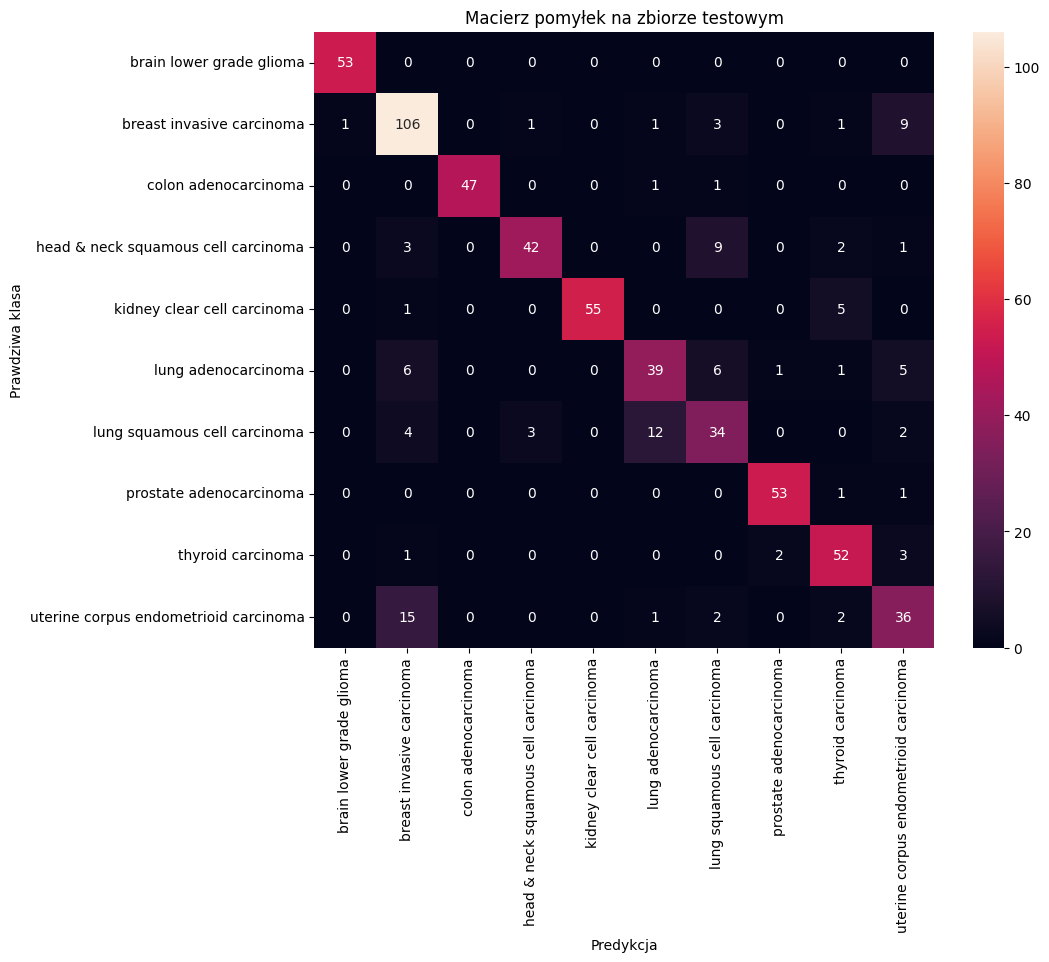

In [20]:
checkpoint = torch.load('best_gnn_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

test_acc, test_f1 = test(test_loader)

print("="*30)
print(f"WYNIKI (TEST SET)")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1-Score (Macro): {test_f1:.4f}")
print("="*30)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(out.argmax(dim=1).cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_mapping.values(), yticklabels=class_mapping.values())
    plt.xlabel('Predykcja')
    plt.ylabel('Prawdziwa klasa')
    plt.title('Macierz pomyłek na zbiorze testowym')
    plt.show()

plot_confusion_matrix(test_loader)